# K Means Clustering

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
import warnings

warnings.filterwarnings('ignore')

In [50]:
X,y=make_blobs(n_samples=1000,n_features=2,centers=3)
pd.DataFrame(X)

,0,1
0,7.383816,3.816433
1,8.193849,3.240401
2,7.153465,4.849144
3,9.254983,1.926555
4,6.143900,-5.659730
...,...,...
995,3.864447,-4.251163
996,-3.352104,-8.173909
997,4.076978,-4.231291
998,8.092006,1.030944


In [51]:
y

array([0, 0, 0, 0, 1, 1, 2, 2, 0, 2, 2, 2, 2, 1, 0, 1, 0, 2, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 2, 2, 0, 1, 2, 2, 1, 0, 0, 1, 0, 2, 1, 0, 2, 1, 2,
       2, 1, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 2, 1, 0, 2, 1, 1, 1, 2, 0,
       0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 1, 1, 1, 2, 1, 1, 0, 2, 1, 2, 0, 0,
       1, 2, 2, 2, 2, 0, 0, 1, 1, 0, 1, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2,
       0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 2, 0, 0, 1, 2, 0, 2, 0, 2, 2, 1,
       2, 1, 1, 0, 1, 2, 2, 1, 2, 2, 2, 0, 1, 1, 0, 1, 0, 0, 1, 2, 0, 1,
       0, 2, 1, 0, 0, 1, 2, 0, 2, 1, 2, 1, 2, 0, 1, 1, 0, 1, 0, 2, 2, 0,
       2, 0, 2, 0, 1, 1, 0, 1, 1, 1, 1, 2, 0, 0, 0, 1, 1, 2, 1, 0, 0, 2,
       0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 0, 1, 0, 2,
       1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 2, 1, 0, 1, 1, 1, 0, 0,
       2, 0, 2, 1, 0, 0, 0, 2, 0, 1, 1, 2, 0, 1, 1, 1, 0, 1, 0, 2, 0, 1,
       0, 1, 0, 1, 1, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 2, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 2, 2, 1, 1, 2, 1, 1, 2, 0,

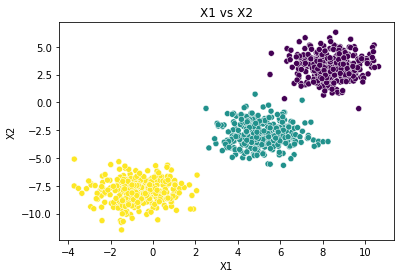

In [52]:
sns.scatterplot(X[:,0],X[:,1],c=y);
plt.title('X1 vs X2')
plt.xlabel('X1')
plt.ylabel('X2');

In [53]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [54]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

## Elbow Method

In [55]:
from sklearn.cluster import KMeans

wcss=[] # Within clusters sum of squares list

for k in range(1,11):
    kmeans=KMeans(init='k-means++',n_clusters=k)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_) # kmeans.inertia_ gives the wcss for the corresponding n_cluster=k

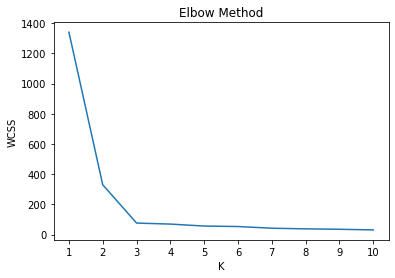

In [56]:
sns.lineplot(range(1,11),wcss);
plt.xticks(range(1,11))
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method');

## An Elbow can be seen from the above graph i.e. The value of K(=3) at this elbow is usually the best choice because adding more clusters after this point provides only small improvements.

In [57]:
kmeans=KMeans(n_clusters=3,init='k-means++')
kmeans.fit_predict(X_train_scaled)

y_pred=kmeans.predict(X_test_scaled)

In [58]:
y_pred

array([2, 0, 1, 2, 1, 0, 0, 1, 0, 2, 0, 2, 2, 0, 1, 1, 1, 0, 2, 0, 0, 1,
       1, 0, 1, 2, 0, 2, 1, 1, 0, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 2, 2, 0,
       1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0,
       1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 2, 2, 0, 2, 2, 0, 1, 0, 0, 2, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 2, 0, 2, 1, 0, 1, 0, 2, 2,
       0, 0, 1, 0, 0, 1, 2, 2, 1, 2, 2, 1, 0, 2, 2, 2, 0, 2, 2, 0, 0, 1,
       2, 2, 2, 1, 2, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 1,
       1, 2, 2, 1, 1, 2, 2, 0, 2, 1, 1, 2, 2, 0, 1, 0, 0, 1, 0, 1, 0, 2,
       0, 2, 1, 0, 1, 2, 0, 0, 0, 1, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 2, 2,
       0, 2, 0, 2, 1, 2, 2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 0, 2, 1, 1, 2,
       2, 1, 2, 1, 2, 0, 1, 0, 1, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 2, 0, 0,
       0, 0, 2, 1, 1, 2, 2, 0, 0, 2, 1, 1, 2, 1, 2, 0, 2, 2, 0, 2, 0, 0,
       2, 0, 2, 0, 2, 2, 0, 1, 2, 0, 1, 1, 0, 0, 2, 1, 0, 1, 2, 0, 1, 1,
       1, 2, 1, 1, 2, 1, 2, 2, 0, 0, 1, 2, 1, 1, 2,

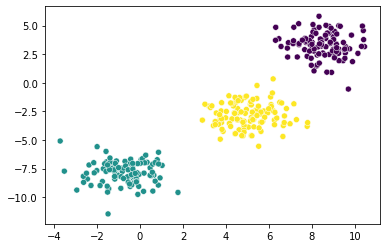

In [59]:
sns.scatterplot(X_test[:,0],X_test[:,1],c=y_pred);